# 딥러닝-전이학습 VGG 모델

CIFAR-10 데이터셋을 사용해 VGG16 기반 전이학습 모델을 만들어봅니다.

이번 노트북의 목표는 다음과 같습니다.

- CIFAR-10 데이터셋의 구조를 확인합니다.
- 학습용 데이터는 `DataLoader`로 준비합니다.
- 검증/테스트 데이터는 텐서로 변환해 평가에 사용합니다.
- ImageNet으로 사전 학습된 VGG16 모델을 불러옵니다.
- VGG16의 마지막 분류층을 CIFAR-10의 10개 클래스에 맞게 교체합니다.
- 학습 곡선, confusion matrix, classification report로 성능을 확인합니다.

![](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)

## 1. 환경 준비

필요한 라이브러리와 반복해서 사용할 함수를 먼저 준비합니다.

### 1.1 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
import torch.nn.functional as F

from torchvision import datasets, transforms

# vgg16
from torchvision.models import vgg16, VGG16_Weights

### 1.2 필요 함수 생성

학습, 검증, 학습 곡선 시각화, 평가 리포트 출력을 위한 함수를 정의합니다.

- `train` 함수: 한 epoch 동안 미니배치 학습을 수행하고 평균 train loss를 반환합니다.

In [3]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

- `evaluate` 함수: validation 또는 test 데이터 전체에 대해 loss와 예측값을 반환합니다.

In [4]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device, batch_size=128):
    """검증/테스트 데이터에 대한 평균 loss와 모델 출력값을 반환합니다."""
    model.eval()

    eval_dataset = TensorDataset(x_val_tensor, y_val_tensor)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0
    pred_list = []

    with torch.no_grad():
        for x, y in eval_loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            pred_list.append(pred.cpu())

    eval_loss = total_loss / len(eval_dataset)
    pred = torch.cat(pred_list, dim=0)

    return eval_loss, pred

- `dl_learning_curve` 함수: train loss, validation loss, validation accuracy를 한 그래프에 표시합니다.

In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- `predict_class`, `evaluate_report` 함수: logits를 클래스 번호로 바꾸고 평가 결과를 출력합니다.

In [6]:
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""
    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)


def evaluate_report(x_test, y_test, model, loss_fn, device, classes):
    """테스트 데이터의 confusion matrix와 classification report를 출력합니다."""
    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = predict_class(pred)

    cm = confusion_matrix(y_test.numpy(), pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues")
    plt.xticks(rotation=90)
    plt.show()

    print("=" * 80)
    print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
    print("-" * 80)
    print(classification_report(y_test.numpy(), pred, target_names=classes))

    return pred

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 1.4 데이터셋 다운로드

CIFAR-10은 10개 클래스의 32x32 컬러 이미지 데이터셋입니다.

VGG16은 ImageNet 데이터로 사전 학습된 모델이므로, 입력 이미지를 ImageNet 평균과 표준편차로 정규화합니다.

In [8]:
weights = VGG16_Weights.DEFAULT
preprocess = weights.transforms()

imagenet_mean = preprocess.mean
imagenet_std = preprocess.std

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:05<00:00, 32.0MB/s]


### 1.5 데이터셋 정보 확인

- 데이터셋 일반 정보

In [9]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

- `dataset.data`는 원본 이미지 배열입니다. CIFAR-10은 `(데이터 수, 높이, 너비, 채널)` 구조로 저장되어 있습니다.

In [10]:
train_dataset.data.shape

(50000, 32, 32, 3)

- target은 각 이미지의 정답 클래스 번호입니다.

In [11]:
train_dataset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

- 클래스 이름을 확인합니다.

In [12]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

- 데이터 1건을 확인합니다. transform이 적용되므로 이미지는 텐서 형태로 반환됩니다.

In [13]:
train_dataset[0]

(tensor([[[-1.1075, -1.3815, -1.2617,  ...,  0.5878,  0.4851,  0.4166],
          [-1.8439, -2.1179, -1.8097,  ..., -0.0116, -0.0801, -0.0287],
          [-1.6898, -1.8439, -1.2788,  ..., -0.0972, -0.0629, -0.2513],
          ...,
          [ 1.4440,  1.3242,  1.2728,  ...,  0.6221, -1.1589, -1.2103],
          [ 0.9646,  0.8447,  1.0673,  ...,  1.0331, -0.4568, -0.6965],
          [ 0.9132,  0.7591,  0.9474,  ...,  1.5810,  0.4679, -0.0116]],
 
         [[-0.9503, -1.2304, -1.1954,  ...,  0.2752,  0.1527,  0.1352],
          [-1.6856, -2.0357, -1.8957,  ..., -0.4951, -0.5826, -0.5126],
          [-1.6155, -1.9132, -1.5630,  ..., -0.5651, -0.5651, -0.7577],
          ...,
          [ 0.9405,  0.6429,  0.7829,  ...,  0.2927, -1.4930, -1.4405],
          [ 0.3978,  0.1176,  0.4853,  ...,  0.5553, -0.9503, -1.1078],
          [ 0.4853,  0.2227,  0.4503,  ...,  1.1856,  0.0301, -0.4251]],
 
         [[-0.7064, -1.0201, -1.0550,  ...,  0.0779, -0.0267, -0.0092],
          [-1.4559, -1.8044,

- 원본 이미지 1장을 시각화합니다.

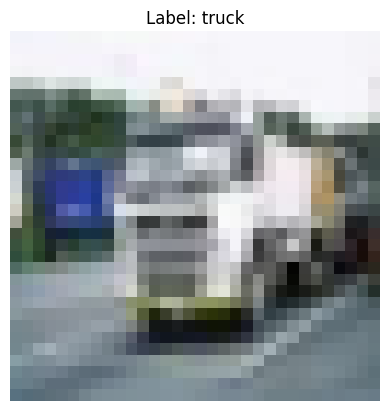

In [14]:
n = 1000
image, label = train_dataset.data[n], train_dataset.targets[n]

plt.imshow(image)
plt.title(f"Label: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

- 랜덤 이미지 32장을 확인합니다.

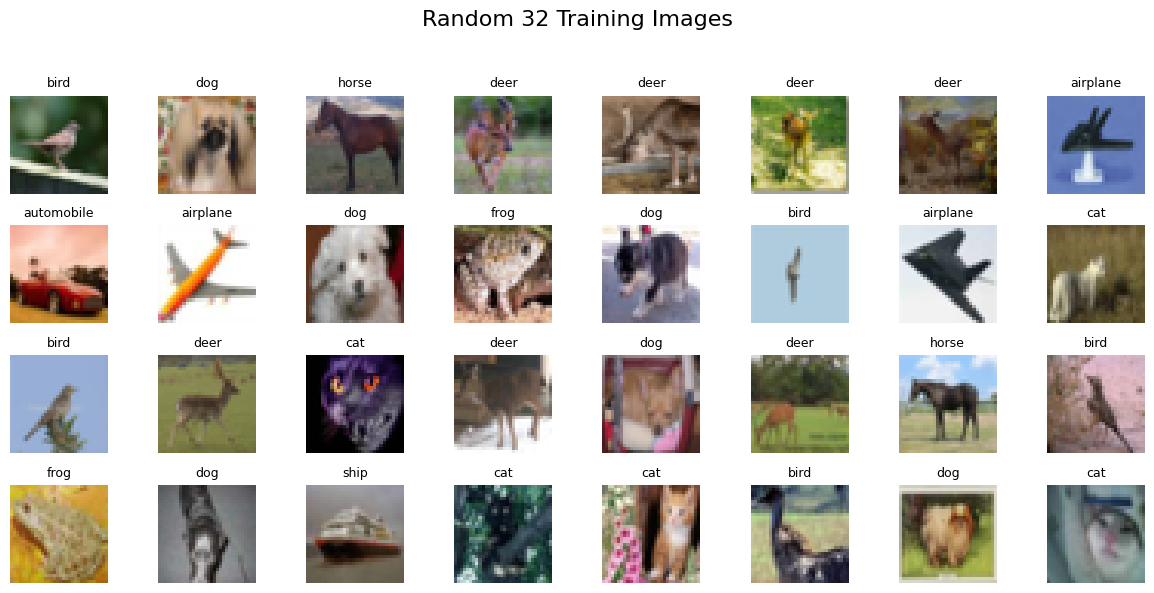

In [15]:
num_images = 32
random_indices = torch.randint(0, len(train_dataset), (num_images,))

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("Random 32 Training Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    index = random_indices[i].item()
    image, label = train_dataset.data[index], train_dataset.targets[index]

    ax.imshow(image)
    ax.set_title(f"{train_dataset.classes[label]}", fontsize=9)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. 데이터 준비

학습 데이터는 `DataLoader`로 만들고, validation/test 데이터는 텐서로 준비합니다.

### 2.1 Train DataLoader 생성

In [16]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

- 첫 번째 배치의 shape을 확인합니다. CIFAR-10 이미지는 컬러 이미지이므로 채널 수가 3입니다.

In [17]:
for x, y in train_dataloader:
    print(f"Shape of x [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


### 2.2 Validation/Test 데이터 준비

`test_dataset.data`에서 원본 이미지를 가져오면 `(N, H, W, C)` 구조입니다. 모델 입력에 맞게 `(N, C, H, W)`로 바꾼 뒤 스케일링과 ImageNet 정규화를 적용합니다.

In [18]:
test_data = test_dataset.data
test_targets = np.array(test_dataset.targets)

In [19]:
# 차원 위치 변경: (N, H, W, C) -> (N, C, H, W)
test_data = test_data.transpose((0, 3, 1, 2))

# 텐서 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.long)

test_data.shape, test_targets.shape

(torch.Size([10000, 3, 32, 32]), torch.Size([10000]))

In [20]:
x_val, x_test = test_data[:5000], test_data[5000:]
y_val, y_test = test_targets[:5000], test_targets[5000:]

x_val.shape, y_val.shape, x_test.shape, y_test.shape

(torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]),
 torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]))

- 스케일링과 정규화를 적용합니다.

In [21]:
def normalize_with_imagenet_stats(x):
    x = x / 255.0
    mean = torch.tensor(imagenet_mean, dtype=torch.float32).view(1, 3, 1, 1)
    std = torch.tensor(imagenet_std, dtype=torch.float32).view(1, 3, 1, 1)
    return (x - mean) / std

x_val = normalize_with_imagenet_stats(x_val)
x_test = normalize_with_imagenet_stats(x_test)

## 3. 모델링

### 3.1 VGG16 구조 직접 확인

VGG16은 convolution block을 깊게 쌓은 모델입니다. 원래 ImageNet 기준 출력 클래스 수는 1000개입니다.

In [22]:
class VGG16(nn.Module):
    def __init__(self, num_classes=1000):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            # 첫 번째 블록
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1), # 1층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1), # 2층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 두 번째 블록
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # 3층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), # 4층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 세 번째 블록
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), # 5층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), # 6층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), # 7층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 네 번째 블록
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1), # 8층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 9층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 10층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 다섯 번째 블록
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 11층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 12층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 13층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### 3.2 전이학습 모델 선언

`torchvision`에서 ImageNet으로 사전 학습된 VGG16 모델을 불러옵니다.

처음 실행할 때는 사전 학습 가중치 파일을 다운로드할 수 있습니다.

In [23]:
# 전이학습 모델 선언
# ImageNet 데이터셋(약 120만정의 컬러이미지, 1000개 클래스)으로 사전 학습
model = vgg16(weights=weights)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 183MB/s]


In [24]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 3.3 Feature Extractor 고정

전이학습에서는 기존 convolution feature extractor는 그대로 두고, 새 문제에 맞는 classifier만 학습하는 방식을 자주 사용합니다.

In [25]:
for param in model.features.parameters():
    param.requires_grad = False

### 3.4 분류층 교체

기존 VGG16은 ImageNet의 1000개 클래스를 출력합니다. CIFAR-10은 10개 클래스이므로 마지막 출력 노드를 10개로 바꿉니다.

In [26]:
n_class = len(classes)

# VGG 모델의 분류기를 우리가 만든 분류기로 덮어씌우기
model.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, n_class),
)

model = model.to(device)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 3.5 Loss와 Optimizer

In [27]:
loss_fn = nn.CrossEntropyLoss()

# model.features -> 학습 안 함
# model.classifier -> 학습함
# requires_grad = True인 파라미터만 골라냄. 즉, 실제로는 새로 바꾼 classifier 부분만 학습
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

## 4. 학습

매 epoch마다 train loss, validation loss, validation accuracy를 기록합니다.

In [28]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t + 1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

Epoch 1, train loss : 1.1186, val loss : 0.9447, val acc : 0.6658
Epoch 2, train loss : 0.9373, val loss : 0.9177, val acc : 0.6864
Epoch 3, train loss : 0.8686, val loss : 0.8877, val acc : 0.6920
Epoch 4, train loss : 0.8125, val loss : 0.8650, val acc : 0.6980
Epoch 5, train loss : 0.7615, val loss : 0.8715, val acc : 0.6974
Epoch 6, train loss : 0.7134, val loss : 0.8636, val acc : 0.7062
Epoch 7, train loss : 0.6657, val loss : 0.8726, val acc : 0.7078
Epoch 8, train loss : 0.6192, val loss : 0.8857, val acc : 0.7038
Epoch 9, train loss : 0.5710, val loss : 0.8965, val acc : 0.7016
Epoch 10, train loss : 0.5275, val loss : 0.9056, val acc : 0.7062
Epoch 11, train loss : 0.4916, val loss : 0.9310, val acc : 0.7012
Epoch 12, train loss : 0.4509, val loss : 0.9513, val acc : 0.7068
Epoch 13, train loss : 0.4123, val loss : 1.0026, val acc : 0.7058
Epoch 14, train loss : 0.3914, val loss : 0.9918, val acc : 0.7052
Epoch 15, train loss : 0.3594, val loss : 1.0279, val acc : 0.7090
Epoc

### 4.1 학습 곡선

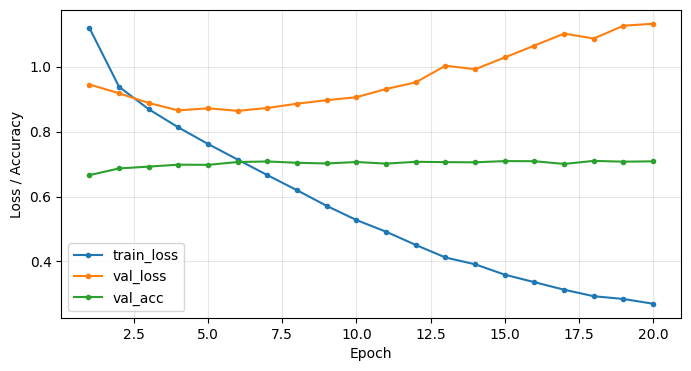

In [29]:
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

## 5. 모델 평가

학습에 사용하지 않은 test 데이터로 최종 성능을 확인합니다.

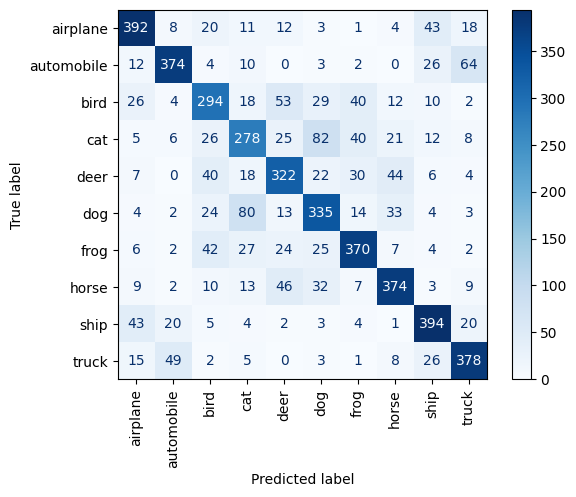

Accuracy : 0.7022
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.76      0.77      0.76       512
  automobile       0.80      0.76      0.78       495
        bird       0.63      0.60      0.62       488
         cat       0.60      0.55      0.57       503
        deer       0.65      0.65      0.65       493
         dog       0.62      0.65      0.64       512
        frog       0.73      0.73      0.73       509
       horse       0.74      0.74      0.74       505
        ship       0.75      0.79      0.77       496
       truck       0.74      0.78      0.76       487

    accuracy                           0.70      5000
   macro avg       0.70      0.70      0.70      5000
weighted avg       0.70      0.70      0.70      5000



In [30]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)